# EDA: IEEE-CIS Fraud Detection

Exploration only. All modelling decisions live in `src/fraud/`. Runs on `data/processed/transactions.parquet` (run `make data` first).

In [1]:
import sys, json
sys.path.insert(0, "../src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 140)
df = pd.read_parquet("../data/processed/transactions.parquet")
split = json.load(open("../data/processed/split.json"))
print(f"{len(df):,} rows, {df.shape[1]} columns, fraud rate {df.isFraud.mean():.4f}")

590,540 rows, 434 columns, fraud rate 0.0350


## Class imbalance and why accuracy is useless
Predicting *legit* for everyone is ~96.5% accurate and catches no fraud. We use PR-AUC, recall at 1% FPR and a business-cost metric instead.

In [2]:
print(df.isFraud.value_counts())
print("accuracy of 'never fraud':", round(1 - df.isFraud.mean(), 4))

isFraud
0    569877
1     20663
Name: count, dtype: int64
accuracy of 'never fraud': 0.965


## Time structure
`TransactionDT` is seconds from an undisclosed reference (~2017-11-30). The fraud rate and volume move over time, so random splits would leak the future; we split by time.

({'train': 413378, 'valid': 88581, 'test': 88581, 'live': 44292},
 {'train': ['2017-12-01', '2018-03-30'],
  'valid': ['2018-03-30', '2018-05-01'],
  'test': ['2018-05-01', '2018-05-31'],
  'live': ['2018-05-15', '2018-05-31']})

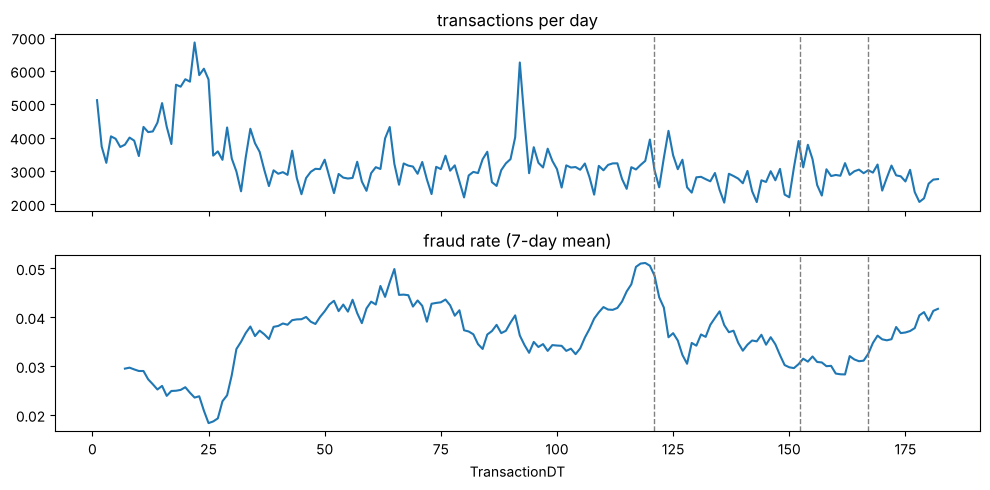

In [3]:
day = df.TransactionDT // 86400
daily = df.groupby(day).agg(n=("isFraud", "size"), fraud_rate=("isFraud", "mean"))
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
daily.n.plot(ax=ax[0], title="transactions per day"); daily.fraud_rate.rolling(7).mean().plot(ax=ax[1], title="fraud rate (7-day mean)")
for k in ["valid_start", "test_start", "live_start"]:
    for a in ax: a.axvline(split["bounds"][k] / 86400, color="grey", ls="--", lw=1)
plt.tight_layout(); split["rows"], split["dates"]

## Amount

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


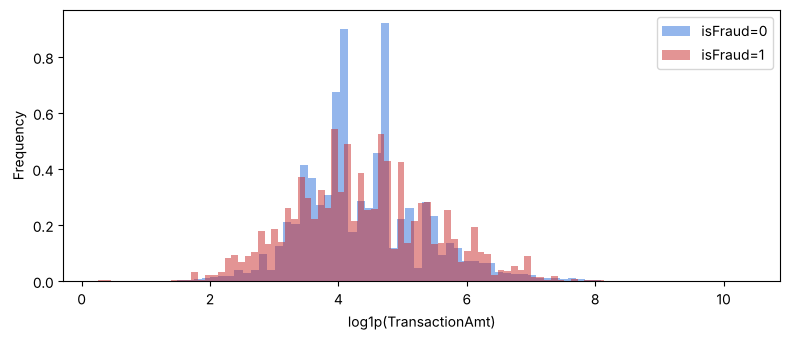

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.5))
for y, c in [(0, "#2a6fdb"), (1, "#c92a2a")]:
    np.log1p(df.loc[df.isFraud == y, "TransactionAmt"]).plot.hist(bins=80, alpha=0.5, density=True, ax=ax, color=c, label=f"isFraud={y}")
ax.set_xlabel("log1p(TransactionAmt)"); ax.legend(); plt.tight_layout()
df.groupby("isFraud").TransactionAmt.describe()

## Categorical risk: product code, card type, email domain, device

             size      mean
ProductCD                  
W          439670  0.020399
C           68519  0.116873
R           37699  0.037826
H           33024  0.047662
S           11628  0.058996 

                    size      mean
card4                             
visa              384767  0.034756
mastercard        189217  0.034331
american express    8328  0.028698
discover            6651  0.077282
NaN                 1577  0.025999 

                   size      mean
card6                            
debit            439938  0.024263
credit           148986  0.066785
NaN                1571  0.024825
debit or credit      30  0.000000
charge card          15  0.000000 

              size      mean
DeviceType                  
NaN         449730  0.021017
desktop      85165  0.065215
mobile       55645  0.101662 



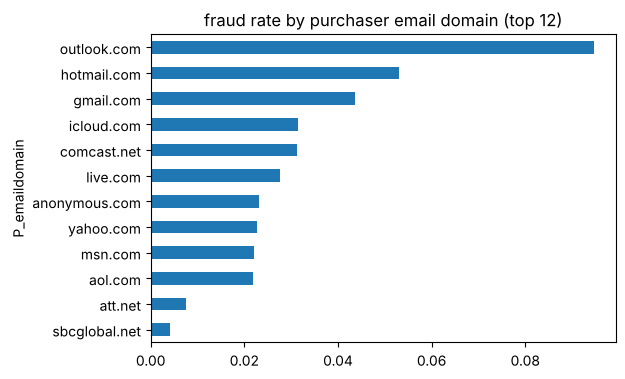

In [5]:
for c in ["ProductCD", "card4", "card6", "DeviceType"]:
    print(df.groupby(c, dropna=False).isFraud.agg(["size", "mean"]).sort_values("size", ascending=False).head(8), "\n")
top = df.P_emaildomain.value_counts().head(12).index
df[df.P_emaildomain.isin(top)].groupby("P_emaildomain").isFraud.mean().sort_values().plot.barh(figsize=(6, 4), title="fraud rate by purchaser email domain (top 12)");

## Missingness
Identity columns are missing for ~76% of transactions (no identity record). V-columns come in blocks with identical null patterns; we drop >85%-null ones and greedily prune |r|>=0.75 (on train only).

In [6]:
na = df.isna().mean()
print("identity join coverage:", round(1 - df.id_01.isna().mean(), 3))
v = na[[c for c in df.columns if c.startswith("V")]]
print(v.round(2).value_counts().sort_index())
print("fraud rate with / without identity:", df.groupby(df.id_01.notna()).isFraud.mean().round(4).to_dict())

identity join coverage: 0.244
0.00    86
0.13    45
0.15    20
0.29    18
0.47    11
0.76    66
0.78    46
0.86    47
Name: count, dtype: int64
fraud rate with / without identity: {False: 0.0209, True: 0.0785}


## Pseudo-user (uid) approximation
There is no user id. `card1 + addr1 + (day - D1)` (card first-seen day) is a common proxy. Check: how stable is it and do frauds cluster within uids?

In [7]:
from fraud.features.definitions import add_base_features
b = add_base_features(df[["TransactionID", "TransactionDT", "TransactionAmt", "card1", "addr1", "D1", "P_emaildomain", "R_emaildomain"]])
g = b.assign(isFraud=df.isFraud).groupby("uid").isFraud.agg(["size", "mean"])
print(f"{len(g):,} uids; median txns/uid {g['size'].median():.0f}; share of uids with >1 txn {(g['size'] > 1).mean():.2f}")
multi = g[g["size"] >= 5]
print("uids with >=5 txns whose fraud share is 0 or 1:", round(((multi["mean"] == 0) | (multi["mean"] == 1)).mean(), 3))

217,850 uids; median txns/uid 1; share of uids with >1 txn 0.43
uids with >=5 txns whose fraud share is 0 or 1: 0.934


Fraud is highly concentrated per uid (most uids are all-legit or all-fraud), which is why past-only per-uid velocity and history features help — and why using any *future* row of the same uid would leak labels.